ALLUVO_Workflow
 ===================================

PHASE 0 — Generate synthetic data  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;              ✔ Done 

PHASE 1 — Virtual Environment   &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;                 ✔ Done  

PHASE 2 — Data Pipeline             &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;             ✔ Done  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;• Load Data  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;• Data Cleaning  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;• Feature Engineering  

PHASE 3 — Interaction Matrix         &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;            ✔ Done  

PHASE 4 — Models  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;• Content-Based Model  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;• Collaborative Filtering    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;  inprogress<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;• Popularity Model  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;• Time Decay Model  

PHASE 5 — Hybrid Model  

PHASE 6 — Evaluation  

PHASE 7 — Save Models  

PHASE 8 — Inference Pipeline  

PHASE 9 — FastAPI (Production)

In [ ]:
#import os
#os.chdir(r"H:\study\AI\vs code\ALLUVO-RecommendationSystem")
#print(os.getcwd())

H:\study\AI\vs code\ALLUVO-RecommendationSystem


Users Dataset

In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(42)

num_users = 2000

# Age distribution (18-60 )
def generate_age():
    r = random.random()
    if r < 0.35:
        return random.randint(18,24)
    elif r < 0.75:
        return random.randint(25,34)
    elif r < 0.95:
        return random.randint(35,45)
    else:
        return random.randint(46,60)

# Interests ( 7 interest)
categories = ["Fashion","Beauty","Fitness","Technology","Home","Sports","Gaming"]

def generate_interests():
    return random.sample(categories, random.randint(2,4))

# Followed brands ( 30 brand)
def generate_followed_brands():
    return random.sample(range(1,31), random.randint(1,5))

users = []

for i in range(1, num_users+1):
    user = {
        "user_id": i,
        "age": generate_age(),
        "gender": random.choice(["Male","Female"]),
        "interests": generate_interests(),
        "followed_brands": generate_followed_brands(),
        "created_at": datetime.now() - timedelta(days=random.randint(0,365)) # Account creation date within the last year
    }
    users.append(user)

users_df = pd.DataFrame(users)

print(users_df.head())

   user_id  age  gender                             interests  \
0        1   32    Male               [Fitness, Home, Gaming]   
1        2   18  Female  [Home, Fashion, Fitness, Technology]   
2        3   21  Female            [Home, Technology, Gaming]   
3        4   32    Male                     [Fashion, Sports]   
4        5   24  Female            [Beauty, Home, Technology]   

    followed_brands                 created_at  
0              [30] 2025-05-14 15:07:01.670697  
1  [25, 29, 27, 30] 2026-01-08 15:07:01.670726  
2  [29, 17, 30, 26] 2025-06-13 15:07:01.670740  
3              [27] 2025-12-15 15:07:01.670752  
4       [21, 2, 22] 2025-12-10 15:07:01.670762  


brands Dataset

In [ ]:
import pandas as pd
import numpy as np
import random

np.random.seed(42)

num_brands = 30

categories = ["Fashion","Beauty","Fitness","Technology","Home","Sports","Gaming"]

brands = []

for i in range(1, num_brands+1):
    brand = {
        "brand_id": i,
        "brand_name": f"Brand {i}",
        "category": random.choice(categories),
        "brand_popularity_score": round(random.uniform(20,100),2)  # realistic number
    }
    brands.append(brand)

brands_df = pd.DataFrame(brands)
print(brands_df.head())

   brand_id brand_name    category  brand_popularity_score
0         1    Brand 1      Beauty                   90.31
1         2    Brand 2      Gaming                   39.51
2         3    Brand 3     Fashion                   78.99
3         4    Brand 4     Fashion                   92.69
4         5    Brand 5  Technology                   41.26


reels Dataset

In [ ]:
num_reels = 3000

reels = []

for i in range(1, num_reels+1):
    brand_id = random.randint(1,30)  # choose a random brand from the 30
    category = None  # will fetch it from Brands_df
    # fetch category from Brands_df
    category = brands_df.loc[brands_df['brand_id'] == brand_id, 'category'].values[0]
    
    reel = {
        "reel_id": i,
        "brand_id": brand_id,
        "category": category,
        "price": round(random.uniform(10,500),2),
        "created_at": datetime.now() - timedelta(days=random.randint(0,90)),
        "video_duration": random.randint(10,60)  # seconds
    }
    reels.append(reel)

reels_df = pd.DataFrame(reels)
print(reels_df.head())

   reel_id  brand_id    category   price                 created_at  \
0        1        13  Technology  383.41 2025-12-07 15:30:44.708503   
1        2        15     Fitness  325.74 2026-02-28 15:30:44.709200   
2        3        13  Technology  156.45 2026-02-21 15:30:44.709716   
3        4        20      Beauty   41.81 2026-01-28 15:30:44.710141   
4        5         4     Fashion  341.84 2026-01-31 15:30:44.710550   

   video_duration  
0              33  
1              13  
2              29  
3              60  
4              24  


interactions Dataset

In [ ]:
interactions = []

for idx, user in users_df.iterrows():
    # each user potentially interacts with 50–150 reels
    num_reels_to_interact = random.randint(50,150)
    reel_sample = reels_df.sample(n=num_reels_to_interact)
    
    for _, reel in reel_sample.iterrows():
        # calculate P(interaction)
        p = 0.1
        if reel['category'] in user['interests']:
            p = 0.6
        elif reel['brand_id'] in user['followed_brands']:
            p = 0.3
        
        interacted = np.random.rand() < p
        if not interacted:
            continue  # skip if the user did not interact
        
        # types of interaction
        like = int(np.random.rand() < 0.3)
        comment = int(np.random.rand() < 0.1)
        purchase = int(np.random.rand() < 0.03)
        watch_ratio = round(random.uniform(0.1,1.0),2)
        if reel['category'] in user['interests'] or reel['brand_id'] in user['followed_brands']:
            watch_ratio = round(random.uniform(0.5,1.0),2)
        
        interaction = {
            "user_id": user['user_id'],
            "reel_id": reel['reel_id'],
            "view": 1,
            "watch_ratio": watch_ratio,
            "like": like,
            "comment": comment,
            "purchase": purchase,
            "timestamp": reel['created_at'] + timedelta(days=random.randint(0,10))
        }
        interactions.append(interaction)

interactions_df = pd.DataFrame(interactions)
print(interactions_df.head())
print("Total interactions:", len(interactions_df))

   user_id  reel_id  view  watch_ratio  like  comment  purchase  \
0        1     1802     1         0.65     1        0         0   
1        1     1191     1         0.96     0        0         1   
2        1      252     1         0.11     0        0         0   
3        1      645     1         0.62     0        0         0   
4        1     2777     1         0.88     1        1         0   

                   timestamp  
0 2026-01-20 15:30:45.336351  
1 2026-01-19 15:30:45.137836  
2 2025-12-10 15:30:44.814443  
3 2026-01-17 15:30:44.949300  
4 2025-12-25 15:30:45.735806  
Total interactions: 65508


load_data

In [ ]:
import pandas as pd
import ast

# load files
users_df = pd.read_csv("data/raw/users.csv")
brands_df = pd.read_csv("data/raw/brands.csv")
reels_df = pd.read_csv("data/raw/reels.csv")
interactions_df = pd.read_csv("data/raw/interactions.csv")

# convert columns that contain lists
users_df['interests'] = users_df['interests'].apply(ast.literal_eval)
users_df['followed_brands'] = users_df['followed_brands'].apply(ast.literal_eval)

# convert dates
users_df['created_at'] = pd.to_datetime(users_df['created_at'])
reels_df['created_at'] = pd.to_datetime(reels_df['created_at'])
interactions_df['timestamp'] = pd.to_datetime(interactions_df['timestamp'])

# quick test
print(users_df.head())
print(brands_df.head())
print(reels_df.head())
print(interactions_df.head())

   user_id  age  gender                            interests  \
0        1   22  Female  [Technology, Gaming, Fashion, Home]   
1        2   33  Female                     [Sports, Beauty]   
2        3   42  Female                 [Sports, Technology]   
3        4   37    Male                    [Beauty, Fashion]   
4        5   31    Male     [Home, Fitness, Sports, Fashion]   

      followed_brands                 created_at  
0             [22, 9] 2025-08-03 15:45:20.197817  
1        [22, 28, 24] 2025-05-22 15:45:20.197847  
2         [3, 23, 15] 2026-02-10 15:45:20.197862  
3  [13, 27, 4, 10, 3] 2025-10-30 15:45:20.197875  
4             [14, 1] 2025-08-28 15:45:20.197889  
   brand_id brand_name    category  brand_popularity_score
0         1    Brand 1  Technology                   95.98
1         2    Brand 2      Gaming                   52.39
2         3    Brand 3     Fitness                   78.73
3         4    Brand 4      Sports                   39.70
4         5   

Feature Engineering

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

# convert user interests to one-hot encoding
mlb = MultiLabelBinarizer()
user_interests = pd.DataFrame(
    mlb.fit_transform(users_df['interests']),
    columns=[f"interest_{c}" for c in mlb.classes_],
    index=users_df.index
)
users_df = pd.concat([users_df, user_interests], axis=1)

# add column for total interactions per user
user_interactions_count = interactions_df.groupby('user_id').size().rename('total_interactions')
users_df = users_df.merge(user_interactions_count, on='user_id', how='left').fillna(0)

# add column for total views per reel
reel_views_count = interactions_df.groupby('reel_id')['view'].sum().rename('total_views')
reels_df = reels_df.merge(reel_views_count, on='reel_id', how='left').fillna(0)

In [ ]:
print(users_df.head())


   user_id  age  gender                            interests  \
0        1   22  Female  [Technology, Gaming, Fashion, Home]   
1        2   33  Female                     [Sports, Beauty]   
2        3   42  Female                 [Sports, Technology]   
3        4   37    Male                    [Beauty, Fashion]   
4        5   31    Male     [Home, Fitness, Sports, Fashion]   

      followed_brands                 created_at  interest_Beauty  \
0             [22, 9] 2025-08-03 15:45:20.197817                0   
1        [22, 28, 24] 2025-05-22 15:45:20.197847                1   
2         [3, 23, 15] 2026-02-10 15:45:20.197862                0   
3  [13, 27, 4, 10, 3] 2025-10-30 15:45:20.197875                1   
4             [14, 1] 2025-08-28 15:45:20.197889                0   

   interest_Fashion  interest_Fitness  interest_Gaming  ...  \
0                 1                 0                1  ...   
1                 0                 0                0  ...   
2          

In [ ]:
print(reels_df.head())

   reel_id  brand_id category   price                 created_at  \
0        1        11   Gaming  301.29 2025-12-05 15:49:20.634276   
1        2        23   Gaming   83.47 2026-02-11 15:49:20.634908   
2        3         4   Sports  471.74 2025-12-29 15:49:20.635441   
3        4        24   Beauty  290.25 2026-01-09 15:49:20.635924   
4        5        11   Gaming   54.94 2026-01-22 15:49:20.636273   

   video_duration  total_views_x  total_views_y  
0              13             28             28  
1              33             26             26  
2              36             25             25  
3              38             15             15  
4              49             32             32  


Interaction Matrix

In [ ]:
interaction_matrix = interactions_df.pivot_table(
    index='user_id',
    columns='reel_id',
    values='watch_ratio',
    fill_value=0
)

print(interaction_matrix.head())

# save a temporary copy for testing
interaction_matrix.to_csv("data/processed/user_item_matrix.csv")

reel_id  1     2     3     4     5     6     7     8     9     10    ...  \
user_id                                                              ...   
1         0.0  0.00  0.00   0.0   0.0   0.0  0.00   0.0   0.0   0.0  ...   
2         0.0  0.51  0.00   0.0   0.0   0.0  0.00   0.0   0.0   0.0  ...   
3         0.0  0.00  0.61   0.0   0.0   0.0  0.00   0.0   0.0   0.0  ...   
4         0.0  0.00  0.00   0.0   0.0   0.0  0.00   0.0   0.0   0.0  ...   
5         0.0  0.00  0.00   0.0   0.0   0.0  0.93   0.0   0.0   0.0  ...   

reel_id  2991  2992  2993  2994  2995  2996  2997  2998  2999  3000  
user_id                                                              
1         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
2         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
3         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
4         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
5         0.0   0.0   0.0   0.0   0.0   0.0   0

Collaborative Filtering (Matrix Factorization)

In [ ]:
from sklearn.decomposition import TruncatedSVD
import numpy as np

# number of latent factors
n_factors = 50

svd = TruncatedSVD(n_components=n_factors, random_state=42)

# transform the matrix
user_latent = svd.fit_transform(interaction_matrix)
item_latent = svd.components_

print("User latent shape:", user_latent.shape)
print("Item latent shape:", item_latent.shape)

User latent shape: (2000, 50)
Item latent shape: (50, 3000)


In [26]:
predicted_matrix = np.dot(user_latent, item_latent)

predicted_df = pd.DataFrame(
    predicted_matrix,
    index=interaction_matrix.index,
    columns=interaction_matrix.columns
)

print(predicted_df.head())

reel_id      1         2         3         4         5         6         7     \
user_id                                                                         
1        0.015864 -0.011917 -0.016780 -0.004151  0.010707  0.004596  0.008659   
2        0.003676  0.017270 -0.001086  0.011078  0.000928 -0.002292  0.005202   
3        0.008200  0.011903  0.043822  0.002892  0.008682  0.046328  0.019253   
4        0.028275 -0.019751  0.000805  0.013518 -0.001955 -0.009487  0.009216   
5        0.009588 -0.012047  0.010642  0.033204  0.009614  0.025486  0.043027   

reel_id      8         9         10    ...      2991      2992      2993  \
user_id                                ...                                 
1        0.011783  0.000719  0.004216  ... -0.004669 -0.012990  0.012726   
2        0.013016  0.001589  0.007165  ...  0.007382 -0.004795  0.009254   
3       -0.000595 -0.007517  0.027612  ...  0.019211 -0.000962  0.013429   
4        0.021495 -0.010344  0.007343  ... -0.021101

In [27]:
already_watched = interaction_matrix > 0
predicted_df[already_watched] = 0

In [54]:
def recommend_cf(user_id, top_k=10):
    user_scores = predicted_df.loc[user_id]
    top_reels = user_scores.sort_values(ascending=False).head(top_k)
    return top_reels

recommend_cf(111)

reel_id
829     0.208848
2186    0.203804
1876    0.197189
2621    0.196950
2388    0.188297
619     0.174191
2698    0.172656
1263    0.171992
1840    0.167003
2019    0.165252
Name: 111, dtype: float64

In [55]:
user = users_df[users_df['user_id'] == 111]
print("User interests:", user['interests'].values)

User interests: [list(['Sports', 'Beauty', 'Home', 'Gaming'])]


In [56]:
top_reels = recommend_cf(111)
top_reel_categories = reels_df[reels_df['reel_id'].isin(top_reels.index)]['category']
print(top_reel_categories)

618      Beauty
828      Beauty
1262     Beauty
1839       Home
1875     Gaming
2018       Home
2185     Beauty
2387     Beauty
2620       Home
2697    Fitness
Name: category, dtype: str


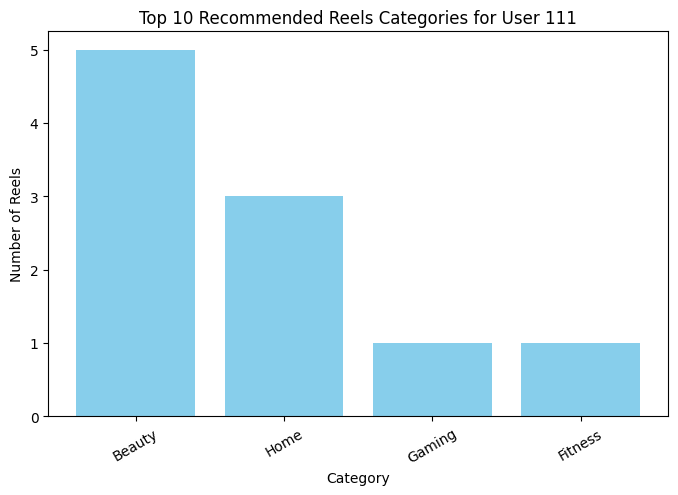

In [ ]:
import matplotlib.pyplot as plt

# user interests
user_id = 111
user_interests = users_df[users_df['user_id'] == user_id]['interests'].values[0]

# recommended reels
top_reels = recommend_cf(user_id)
top_reel_categories = reels_df[reels_df['reel_id'].isin(top_reels.index)]['category']

# count reels per category
category_counts = top_reel_categories.value_counts()

# plot Bar Chart
plt.figure(figsize=(8,5))
bars = plt.bar(category_counts.index, category_counts.values, color='skyblue')
plt.title(f"Top {len(top_reels)} Recommended Reels Categories for User {user_id}")
plt.ylabel("Number of Reels")
plt.xlabel("Category")

# highlight user interests
for bar in bars:
    if bar.get_x() + bar.get_width()/2 in [top_reel_categories.index[top_reel_categories == c][0] for c in user_interests if c in category_counts.index]:
        bar.set_color('orange')

# add line or text to indicate user interests
plt.xticks(rotation=30)
plt.show()

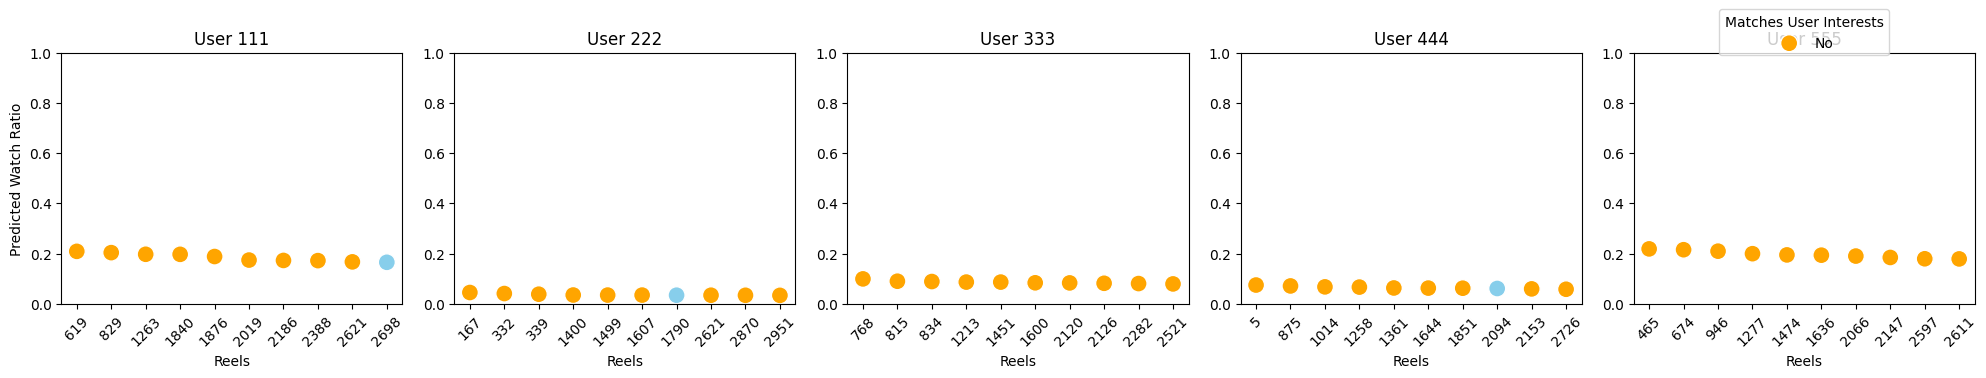

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# select 5 users
user_ids = [111, 222, 333, 444, 555]

plt.figure(figsize=(20, 4))  # 5 plots side by side

for i, user_id in enumerate(user_ids):
    user_interests = users_df[users_df['user_id'] == user_id]['interests'].values[0]
    
    # Top 10 CF recommendations
    top_reels = recommend_cf(user_id, top_k=10)
    top_reels_df = reels_df[reels_df['reel_id'].isin(top_reels.index)].copy()
    top_reels_df['score'] = top_reels.values
    
    # matches with user interests
    top_reels_df['matches_interest'] = top_reels_df['category'].apply(lambda x: x in user_interests)
    
    # sort by score
    top_reels_df.sort_values('score', ascending=False, inplace=True)
    
    # subplot for each user
    plt.subplot(1, 5, i+1)
    sns.scatterplot(
        x=range(len(top_reels_df)),
        y='score',
        hue='matches_interest',
        palette={True: 'orange', False: 'skyblue'},
        s=150,
        data=top_reels_df,
        legend=False  # remove legend for each subplot
    )
    plt.title(f"User {user_id}")
    plt.xticks(range(len(top_reels_df)), top_reels_df['reel_id'], rotation=45)
    plt.ylim(0,1)  # watch_ratio is always between 0 and 1
    plt.xlabel("Reels")
    plt.ylabel("Predicted Watch Ratio" if i==0 else "")
    
# single legend above all plots
plt.legend(title="Matches User Interests", loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2, labels=["No","Yes"])
plt.tight_layout()
plt.show()